# Testing MPNN Models trained with ZINC and SPICE Datasets

## Zinc Dataset

In [1]:
from torch.utils.data import random_split
import numpy as np
import importlib
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("dataset_loader.log"),
        logging.StreamHandler()
    ]
)

In [2]:
from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelEncoder import ModelEncoder

zinc_dataset_encoder = ModelEncoder(collapse=True)

# Load the ZINC files
zinc_sdf_path = "./data/parm_at_Frosst/zinc.sdf"
zinc_json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
zinc_dataset = GNNdataset(zinc_sdf_path, 
                              zinc_json_labels, 
                              directed_graph=True, 
                              labeled=True,
                              encoder=zinc_dataset_encoder)

[2025-05-04 21:58:54,511] INFO - Enabling RDKit 2024.03.5 jupyter extensions
[2025-05-04 21:58:55,091] INFO - NumExpr defaulting to 10 threads.
[2025-05-04 21:58:55,258] INFO - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-05-04 21:58:55,292] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-05-04 21:58:55,320] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-05-04 21:58:55,401] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-05-04 21:58:55,460] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-05-04 21:58:55,520] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-05-04 21:58:55,571] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-05-04 21:58:55,590] WARNING - Atom count mis

FULL DATASET (encoded):


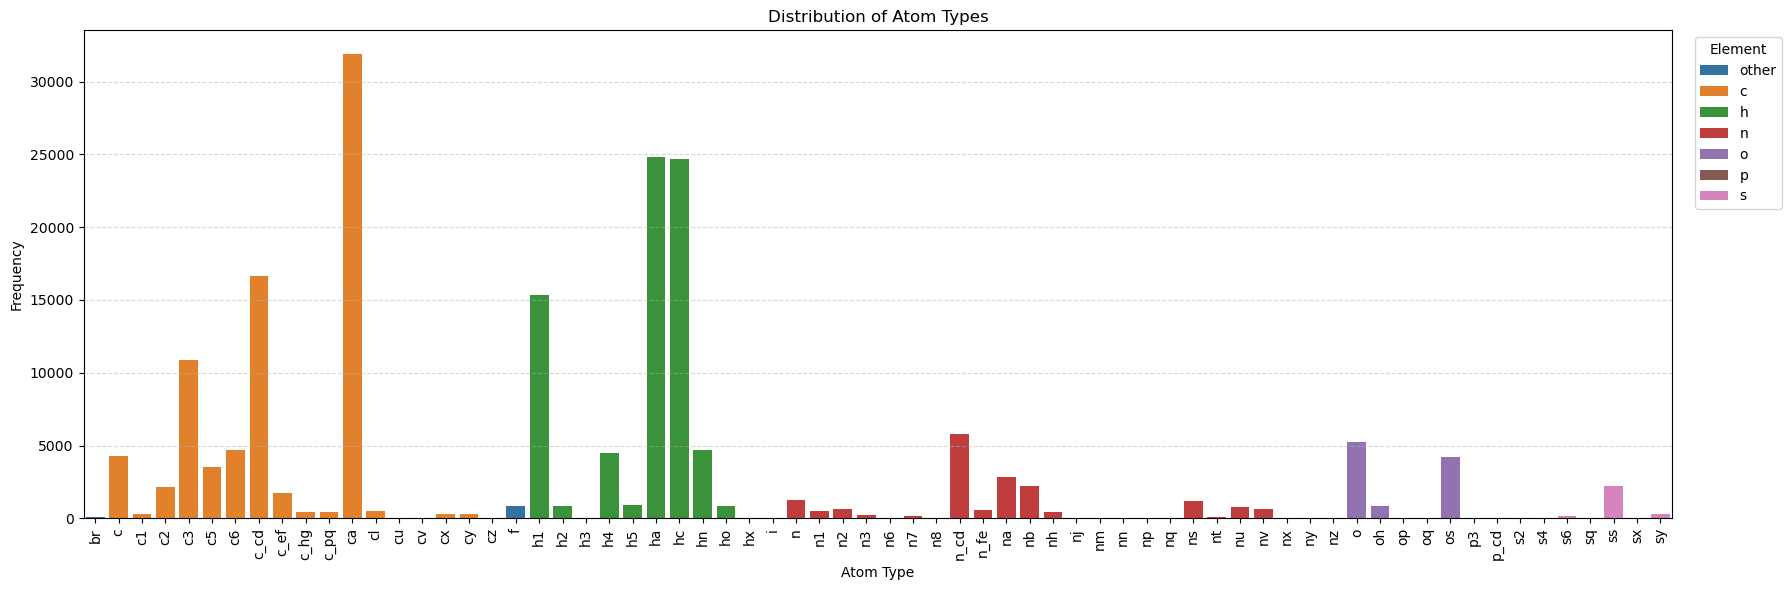

In [3]:
from atoMLtype.analysis.accuracy_counts import plot_atom_distribution

# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(zinc_dataset))
test_size = len(zinc_dataset) - train_size
train_dataset, test_dataset = random_split(zinc_dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(zinc_dataset_encoder.inverse_transform(zinc_dataset.encoded_labels)))

AtomBondMPNN - Number of parameters: 10985550
--- Fold 1/5 ---


Epoch 1: Train Loss = 1.7022, Val Loss = 0.1399
Epoch 6: Train Loss = 0.0387, Val Loss = 0.0530
Epoch 11: Train Loss = 0.0195, Val Loss = 0.0418
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.0335, Val Loss = 0.0208
Epoch 6: Train Loss = 0.0140, Val Loss = 0.0192
Epoch 11: Train Loss = 0.0148, Val Loss = 0.0218
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0177, Val Loss = 0.0231
Epoch 6: Train Loss = 0.0092, Val Loss = 0.0228
Epoch 11: Train Loss = 0.0086, Val Loss = 0.0301
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0177, Val Loss = 0.0440
Epoch 6: Train Loss = 0.0113, Val Loss = 0.0139
Epoch 11: Train Loss = 0.0198, Val Loss = 0.0184
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0173, Val Loss = 0.0100
Epoch 6: Train Loss = 0.0121, Val Loss = 0.0046
Epoch 11: Train Loss = 0.0130, Val Loss = 0.0183


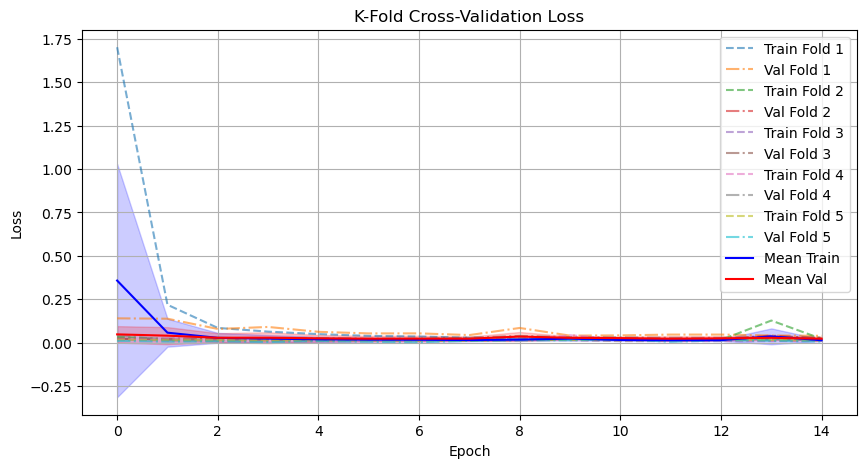

In [4]:
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN
from atoMLtype.models.ModelTrainer import GNNTrainer

AtomMPNN_zinc = AtomBondMPNN(atom_input_dim=train_dataset[0].x.shape[1], 
                                      bond_input_dim=train_dataset[0].edge_attr.shape[1], 
                                      hidden_dim=512,
                                      encoder=zinc_dataset_encoder, 
                                      num_layers=10,
                                      use_attention=True)

trainer_AtomMPNN_zinc = GNNTrainer(AtomMPNN_zinc, 
                                   dataset=train_dataset, 
                                   batch_size=32, learning_rate=0.001,
                                   epochs=15, 
                                   k_folds=5, 
                                   random_seed=21)

loss_output = trainer_AtomMPNN_zinc.train(verbose=True)



In [5]:
from atoMLtype.models.ModelEngine import ModelEngine

modelEngine_zinc = ModelEngine(model=AtomMPNN_zinc, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

zinc_record = modelEngine_zinc.predict(analysis=True)


In [6]:
zinc_record.summary()

Prediction Summary: 18376/18416 correct (99.78% accuracy)
True label distribution: Counter({'ca': 3197, 'ha': 2544, 'hc': 2431, 'c_cd': 1712, 'h1': 1450, 'c3': 1093, 'n_cd': 561, 'o': 511, 'hn': 473, 'c6': 445, 'h4': 438, 'c': 409, 'os': 392, 'c5': 297, 'na': 282, 'ss': 257, 'nb': 237, 'c2': 207, 'c_ef': 165, 'n': 116, 'ns': 112, 'f': 87, 'nu': 83, 'h5': 79, 'oh': 74, 'ho': 74, 'h2': 73, 'cl': 71, 'nv': 67, 'n_fe': 57, 'n2': 56, 'c_pq': 50, 'nh': 44, 'n1': 42, 'sy': 35, 'cy': 34, 'c_hg': 32, 'c1': 26, 'cx': 22, 'n3': 19, 'nt': 14, 's6': 12, 'br': 8, 'n7': 8, 'sx': 4, 'i': 3, 'nn': 2, 'np': 2, 'nj': 2, 'h3': 1, 'n8': 1, 'cu': 1, 'op': 1, 'cz': 1, 's4': 1, 'p_cd': 1})
Pred label distribution: Counter({'ca': 3202, 'ha': 2544, 'hc': 2431, 'c_cd': 1689, 'h1': 1450, 'c3': 1093, 'n_cd': 558, 'o': 511, 'hn': 473, 'c6': 445, 'h4': 438, 'c': 408, 'os': 392, 'c5': 297, 'na': 282, 'ss': 257, 'nb': 241, 'c2': 208, 'c_ef': 183, 'n': 116, 'ns': 112, 'f': 87, 'nu': 83, 'h5': 79, 'oh': 74, 'ho': 74, 'h

In [12]:
AtomMPNN_zinc.save("./saved_models/AtomMPNN_Zinc.mdl")

Model + encoder + metadata saved to ./saved_models/AtomMPNN_Zinc.mdl


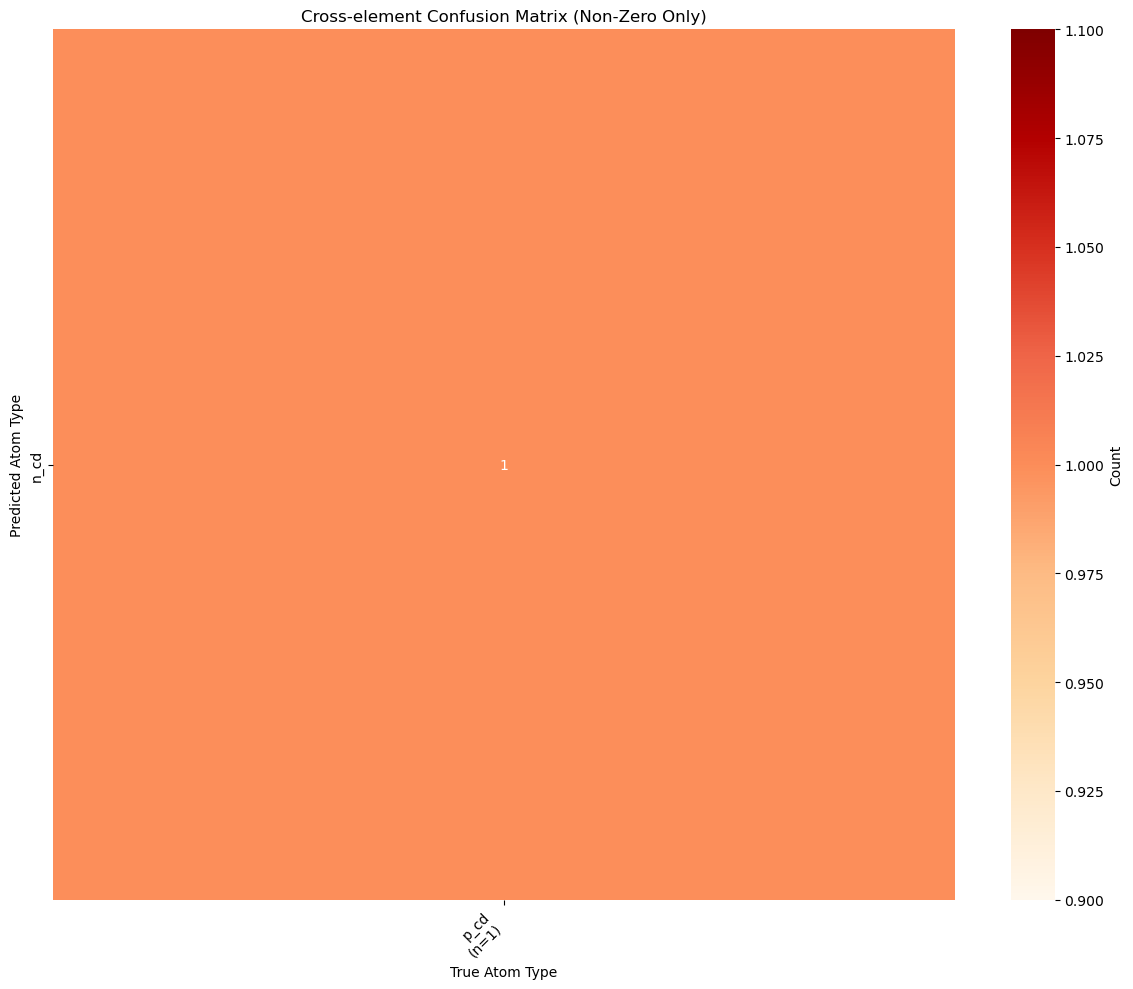

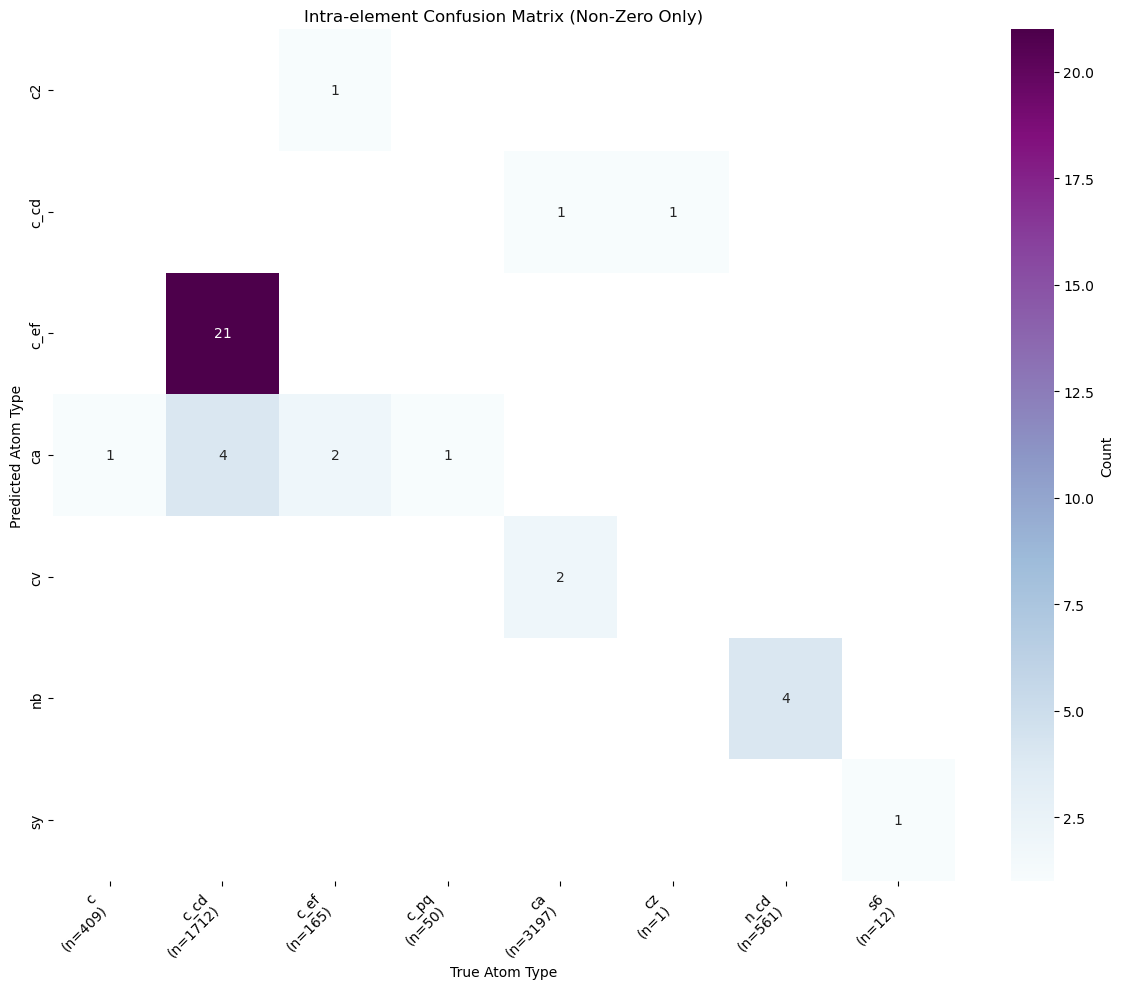

In [7]:
from atoMLtype.analysis.confusionMatrices import plot_full_confusion_matrices

plot_full_confusion_matrices(zinc_record)

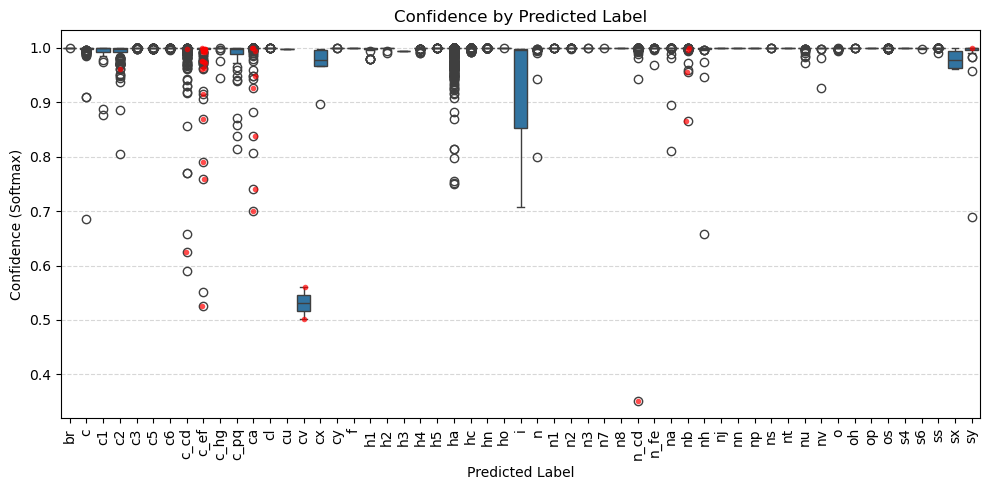

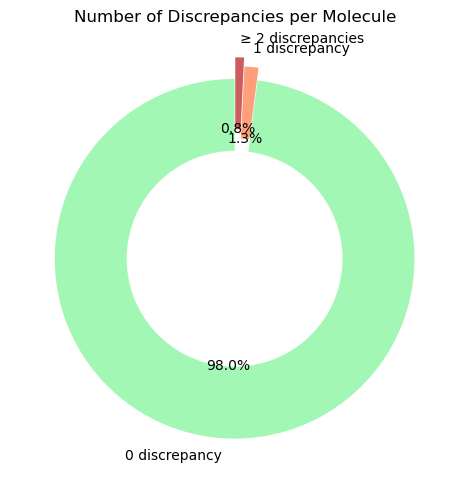

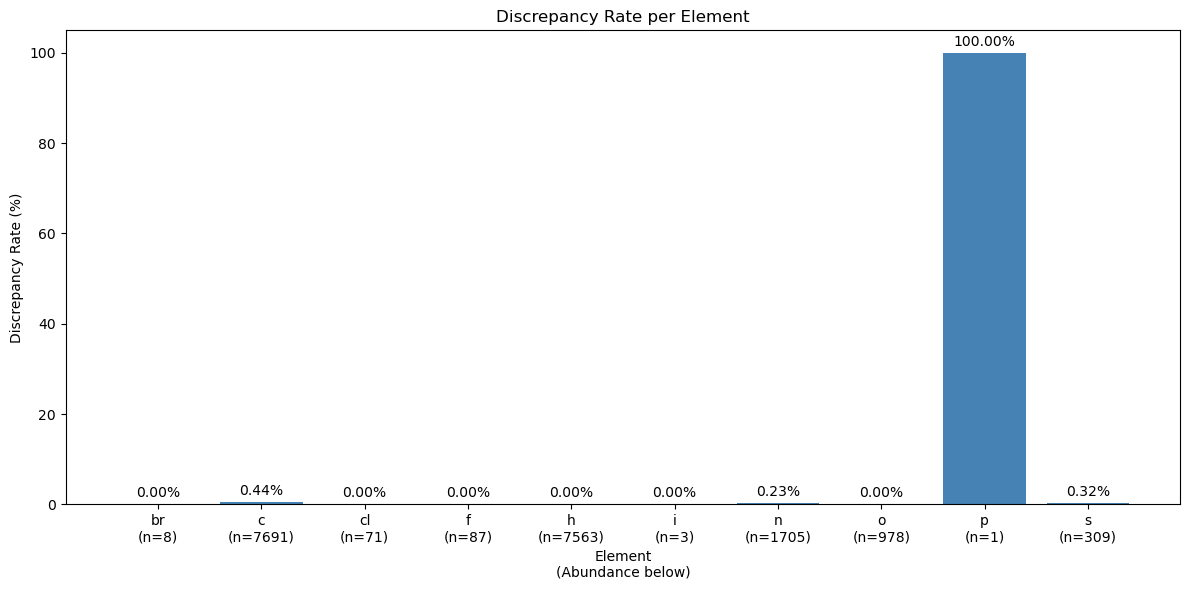

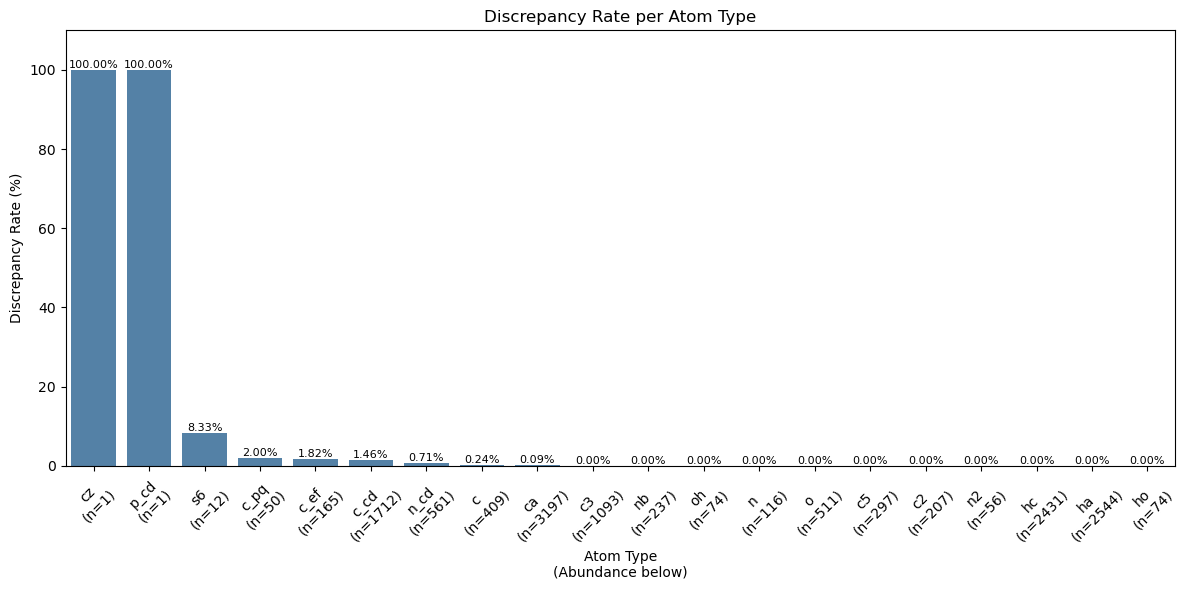

In [8]:
from atoMLtype.analysis.discrepancies import plot_confidence_by_pred_label, plot_discrepancy_distribution, plot_element_discrepancy_rate, plot_discrepancy_rate_by_atom_type


plot_confidence_by_pred_label(zinc_record, 
                              sort_by='alphabetical',
                              show_mismatch=True,
                              showfliers=True, 
                              figsize=(10, 5))

plot_discrepancy_distribution(zinc_record)

valid_elements = {
        "f", "cl", "br", "i", "c", "h", "n", "o", "s", "p"
    }

plot_element_discrepancy_rate(zinc_record, valid_elements)

plot_discrepancy_rate_by_atom_type(zinc_record)

/Users/brobello/Capstone_biovia/Biovia-1/atoMLtype/analysis/molecule_embeddings.py:107: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


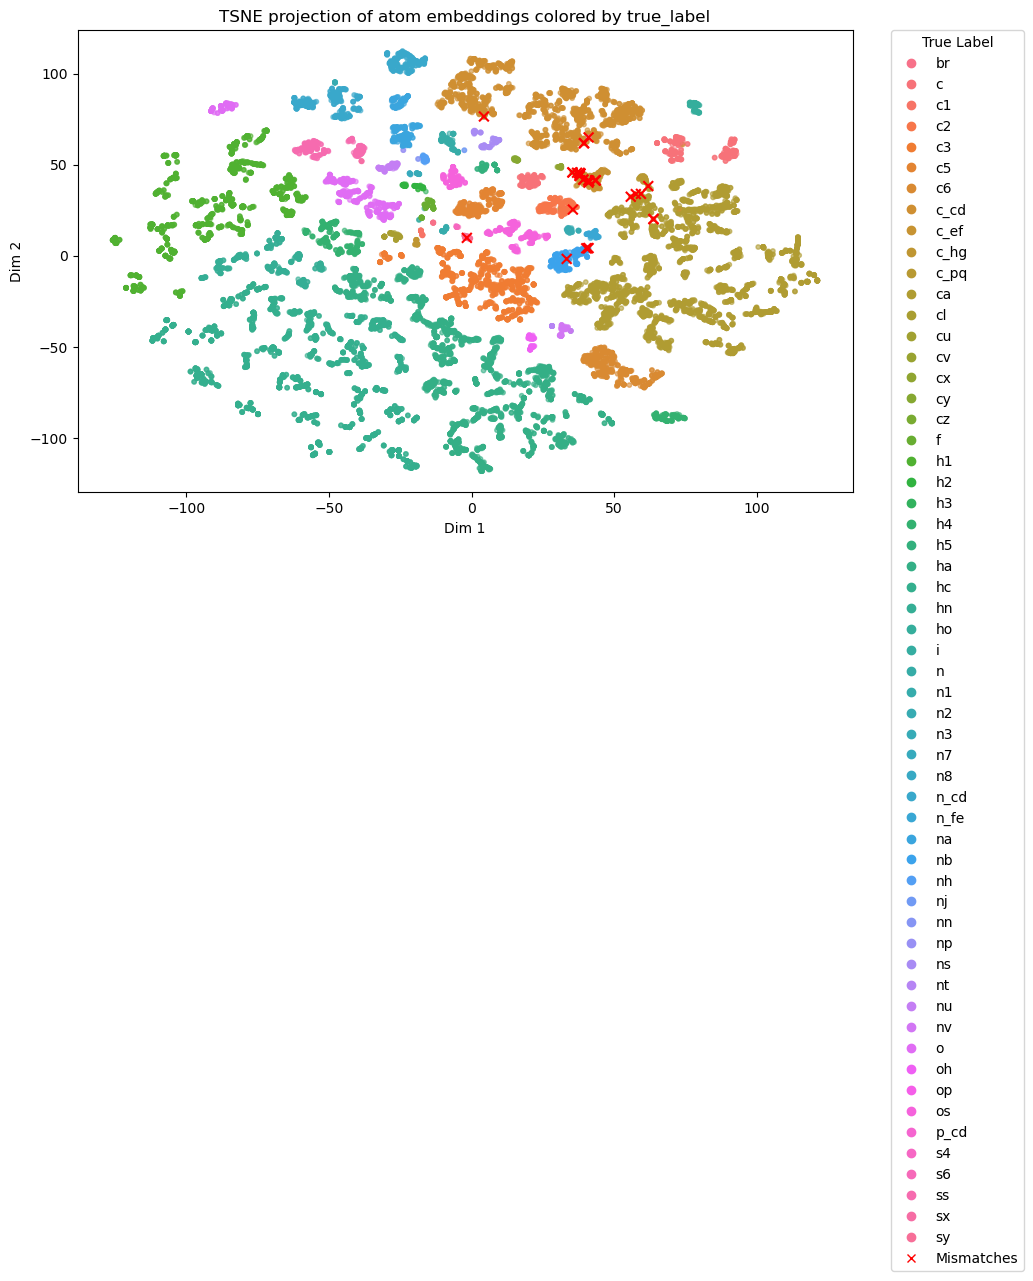

In [9]:
from atoMLtype.analysis.molecule_embeddings import visualize_prediction_embeddings

visualize_prediction_embeddings(
    pred_record=zinc_record,
    key='clf_embeddings',
    method='tsne'
)

In [10]:
len(zinc_record.mismatched_molecules)

13

ZINC17020202 atom 5, pred AT sy for s6
ZINC17020202 atom 8, pred AT ca for c_cd
ZINC17020202 atom 9, pred AT ca for c_cd
ZINC17020202 atom 11, pred AT nb for n_cd
ZINC17020202 atom 12, pred AT ca for c
ZINC17020202 atom 14, pred AT nb for n_cd
ZINC17020202 atom 15, pred AT nb for n_cd


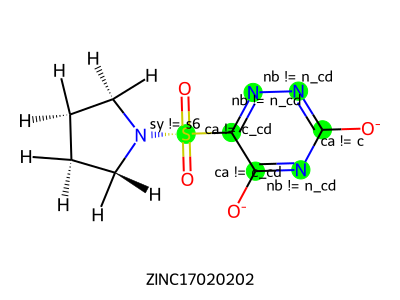

ZINC00517372 atom 12, pred AT c_ef for c_cd


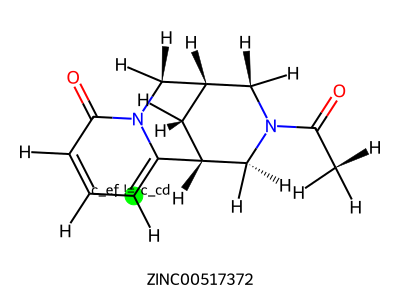

ZINC05553161 atom 9, pred AT c2 for c_ef


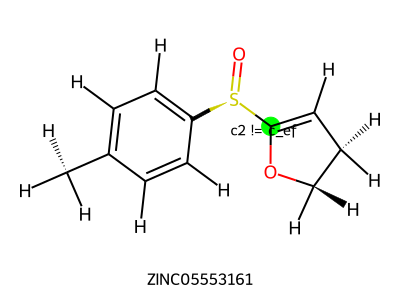

ZINC01584937 atom 7, pred AT ca for c_cd
ZINC01584937 atom 11, pred AT nb for n_cd


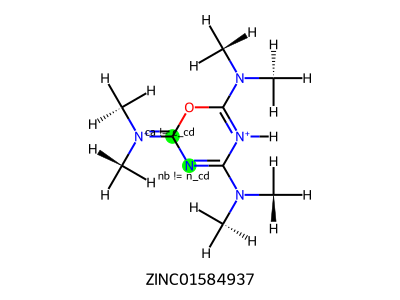

ZINC52566278 atom 10, pred AT ca for c_ef


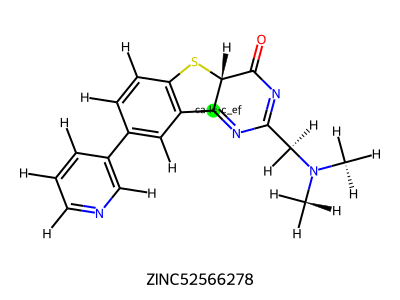

ZINC47843887 atom 7, pred AT ca for c_cd


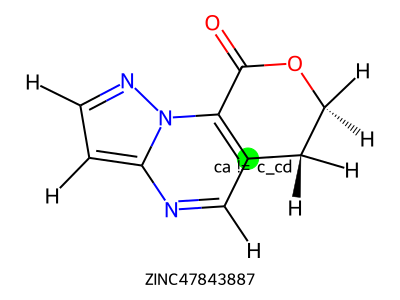

ZINC19419529 atom 9, pred AT c_cd for ca


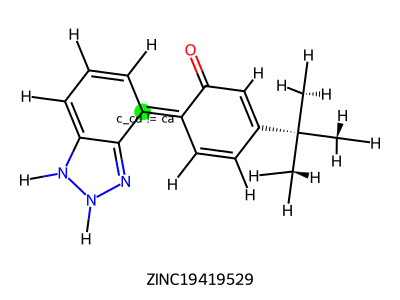

ZINC02077542 atom 0, pred AT c_ef for c_cd
ZINC02077542 atom 1, pred AT c_ef for c_cd
ZINC02077542 atom 2, pred AT c_ef for c_cd
ZINC02077542 atom 3, pred AT c_ef for c_cd
ZINC02077542 atom 4, pred AT c_ef for c_cd
ZINC02077542 atom 5, pred AT c_ef for c_cd
ZINC02077542 atom 6, pred AT c_ef for c_cd
ZINC02077542 atom 7, pred AT c_ef for c_cd
ZINC02077542 atom 8, pred AT c_ef for c_cd
ZINC02077542 atom 9, pred AT c_ef for c_cd


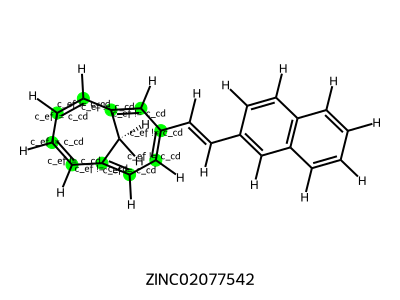

ZINC20458686 atom 10, pred AT ca for c_ef


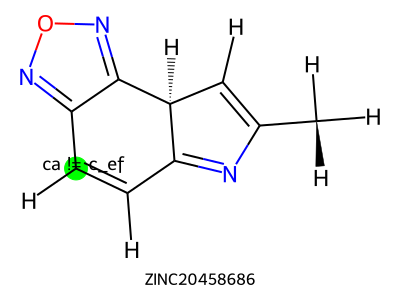

ZINC15226782 atom 7, pred AT c_cd for cz


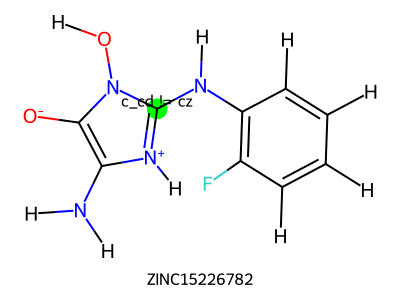

ZINC03847119 atom 0, pred AT c_ef for c_cd
ZINC03847119 atom 1, pred AT c_ef for c_cd
ZINC03847119 atom 2, pred AT c_ef for c_cd
ZINC03847119 atom 3, pred AT c_ef for c_cd
ZINC03847119 atom 4, pred AT c_ef for c_cd
ZINC03847119 atom 5, pred AT c_ef for c_cd
ZINC03847119 atom 6, pred AT c_ef for c_cd
ZINC03847119 atom 7, pred AT c_ef for c_cd
ZINC03847119 atom 8, pred AT c_ef for c_cd
ZINC03847119 atom 9, pred AT c_ef for c_cd


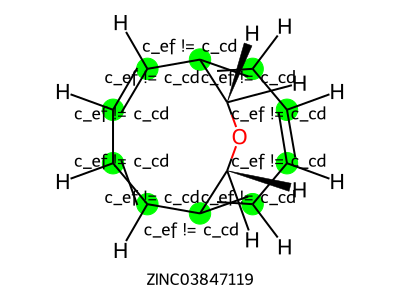

ZINC05722977 atom 6, pred AT n_cd for p_cd


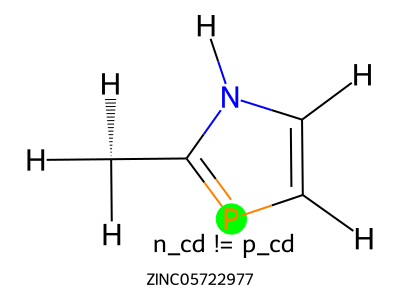

ZINC08385154 atom 14, pred AT cv for ca
ZINC08385154 atom 15, pred AT cv for ca
ZINC08385154 atom 18, pred AT ca for c_pq


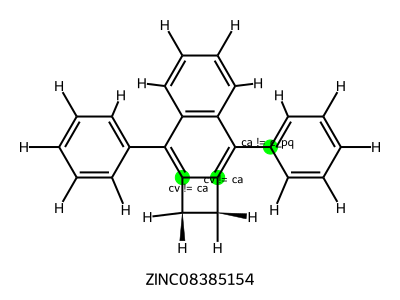

In [11]:
from atoMLtype.analysis.molecule_embeddings import draw_molecule_with_mismatches_labeled


for mol_name, atom_preds in zinc_record.mismatched_molecules.items():
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol = zinc_dataset.get_mol(mol_name)

    img = draw_molecule_with_mismatches_labeled(mol, atom_preds)
    display(img)  # or img.save(f"{mol_name}_mismatch.png")